## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [ ]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [2]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Dữ liệu ở đây là về mức độ bức xạ của Mặt Trời, cụ thể là lượng bức xạ Mặt Trời đi vào bề mặt sau khi đã trừ đi những phần bị cản lại, đơn vị đo là W/m². 

Ngoài việc bức xạ mạnh hay yếu do chính Mặt Trời, thì cũng có những yếu tố khác tác động như mây dày hay mây mỏng, bề mặt có nhiều cây cối không, hay mức độ ô nhiễm trong không khí. Nhờ xem xét xu hướng lâu dài của bức xạ, ta sẽ biết được toàn cầu đang tối đi hay sáng lên theo thời gian.

Tạo các biến:
- df_daily: Bức xạ Mặt Trời theo ngày
- df_monthly: Bức xạ Mặt Trời theo tháng
- df_clim: Bức xạ Mặt Trời trung bình từng tháng
- df_anom: Dị thường bức xạ Mặt Trời

In [3]:
def get_solar_radiation_data_optimized(folder_path, solar_name):
    # Load datasets
    ds_rad = preprocess(xr.open_dataset(os.path.join(folder_path, solar_name))) 

    # Extract variables safely
    var_rad = list(ds_rad.data_vars)

    # From Xarray DataSet to DataArray
    rad = ds_rad[var_rad]

    # Spatial mean reduction
    rad = rad.mean(dim=['latitude', 'longitude']).compute()

    # Close dataset
    ds_rad.close()

    daily_rad   = rad.resample(time="1D").mean()
    monthly_rad = daily_rad.resample(time="1ME").mean()

    clim_rad  = daily_rad.groupby("time.month").mean("time")
    anom_rad  = daily_rad.groupby("time.month") - clim_rad

    df_daily = daily_rad.to_dataframe()
    df_monthly = monthly_rad.to_dataframe()
    df_clim = clim_rad.to_dataframe()
    df_anom = anom_rad.to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim, df_anom

In [4]:
df_daily, df_monthly, df_clim, df_anom = get_solar_radiation_data_optimized(FOLDER_PATH, 'mean_surface_net_short_wave_radiation_flux_merged.nc')

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,avg_snswrf
0,1980-01-01,186.165558
1,1980-01-02,188.935776
2,1980-01-03,190.451904
3,1980-01-04,171.583221
4,1980-01-05,155.817520


In [6]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,avg_snswrf
0,1980-01-31,172.022720
1,1980-02-29,177.157990
2,1980-03-31,219.356659
3,1980-04-30,221.403549
4,1980-05-31,206.787994


In [7]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,avg_snswrf
0,1,160.916641
1,2,183.028000
2,3,204.906494
3,4,217.917679
4,5,205.141312


In [8]:
df_anom = df_anom.drop(columns=['number']).reset_index()
df_anom.head()

,time,month,avg_snswrf
0,1980-01-01,1,25.248917
1,1980-01-02,1,28.019135
2,1980-01-03,1,29.535263
3,1980-01-04,1,10.666580
4,1980-01-05,1,-5.099121


## 1. Xu hướng bức xạ trung bình năm (Tín hiệu tối đi / sáng lên)

Biểu đồ này đo xu hướng tổng thể qua 45 năm từ 1980 - 2024 dựa trên một đường tuyến tính (Linear). Đồng thời có cả Piecewise chia thành 2 giai đoạn.

Tuy nhiên nhìn vào biểu đồ, ta thấy không có sự thay đổi rõ ràng. Dữ liệu khá hỗn loạn, biến động trong năm rất mạnh, đơn lẻ theo từng năm và không có quy luật gì, không có xu hướng lâu dài. Mọi daoo động là do tự nhiên.

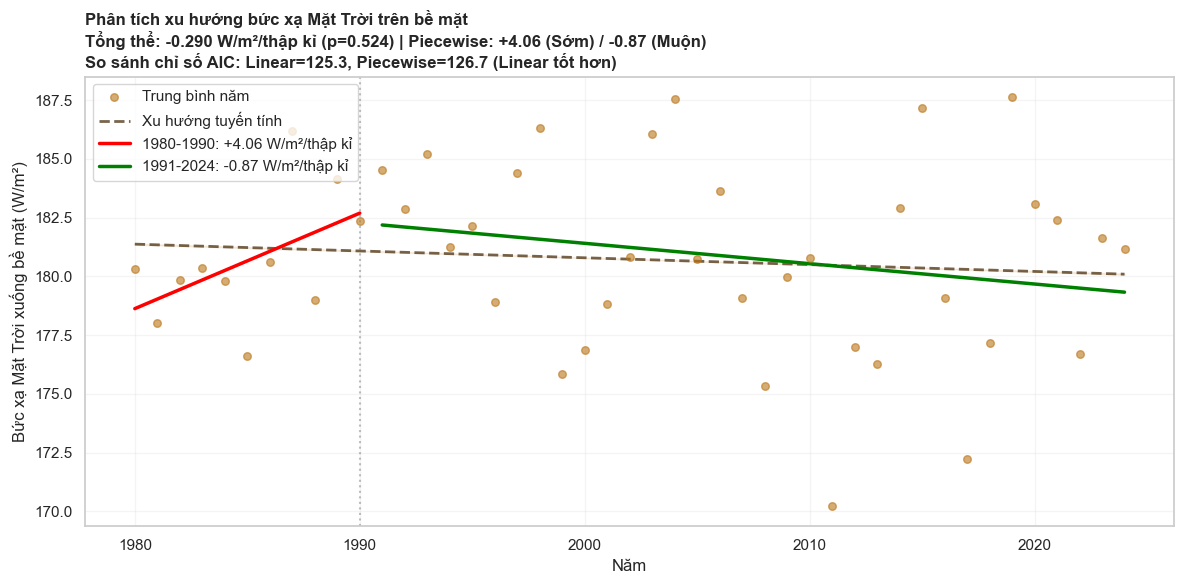

In [10]:
df_daily['time'] = pd.to_datetime(df_daily['time'])
annual_rad = df_daily.resample('YE', on='time').mean()
years = annual_rad.index.year.values
vals = annual_rad['avg_snswrf'].values

# Simple Linear Regression
slope, intercept, r, p, se = stats.linregress(years, vals)
fit_linear = intercept + slope * years
n = len(vals)

# Calculate AIC for Linear Model (k=2: slope, intercept)
rss_lin = np.sum((vals - fit_linear)**2)
aic_lin = n * np.log(rss_lin/n) + 2 * 2

# Piecewise Linear (Breakpoint 1990)
mask_early = years <= 1990
mask_late = years > 1990

# Fit early segment
s1, i1, r1, p1, _ = stats.linregress(years[mask_early], vals[mask_early])
# Fit late segment
s2, i2, r2, p2, _ = stats.linregress(years[mask_late], vals[mask_late])

# Predict for piecewise (for AIC and plotting)
fit_pw = np.zeros_like(vals)
fit_pw[mask_early] = i1 + s1 * years[mask_early]
fit_pw[mask_late] = i2 + s2 * years[mask_late]

# Calculate AIC for Piecewise Model (k=4: 2 slopes, 2 intercepts)
rss_pw = np.sum((vals - fit_pw)**2)
aic_pw = n * np.log(rss_pw/n) + 2 * 4

# Determine which model is better
better_model = "Piecewise" if aic_pw < aic_lin else "Linear"

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter points
ax.scatter(years, vals, s=30, color="#BA7517", alpha=0.6, label="Trung bình năm", zorder=3)

# Linear Trend + Confidence Interval
x_mean = np.mean(years)
x_sum_sq = np.sum((years - x_mean)**2)
# Standard error of the prediction (simplified for plotting)
ci95 = 1.96 * se * np.sqrt(1/n + (years - x_mean)**2 / x_sum_sq)

ax.plot(years, fit_linear, color="#412402", linewidth=2, linestyle="--", label="Xu hướng tuyến tính", alpha=0.7)
ax.fill_between(years, fit_linear - ci95, fit_linear + ci95, color="#BA7517", alpha=0.1)

# Plot Piecewise Segments
ax.plot(years[mask_early], fit_pw[mask_early], color="red", linewidth=2.5, label=f"1980-1990: {s1*10:+.2f} W/m²/thập kỉ")
ax.plot(years[mask_late], fit_pw[mask_late], color="green", linewidth=2.5, label=f"1991-2024: {s2*10:+.2f} W/m²/thập kỉ")

# Vertical line for breakpoint
ax.axvline(1990, color="grey", linestyle=":", alpha=0.5)

# Formatting
title = (f"Phân tích xu hướng bức xạ Mặt Trời trên bề mặt\n"
         f"Tổng thể: {slope*10:+.3f} W/m²/thập kỉ (p={p:.3f}) | "
         f"Piecewise: {s1*10:+.2f} (Sớm) / {s2*10:+.2f} (Muộn)\n"
         f"So sánh chỉ số AIC: Linear={aic_lin:.1f}, Piecewise={aic_pw:.1f} ({better_model} tốt hơn)")

ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
ax.set_ylabel("Bức xạ Mặt Trời xuống bề mặt (W/m²)")
ax.set_xlabel("Năm")
ax.grid(True, alpha=0.2)
ax.legend(frameon=True, loc='upper left')

plt.tight_layout()
plt.show()

## 2. Heatmap dị thường trong bức xạ Mặt Trời

Dựa vào heatmap để xem những dị thường trong từng tháng một trong suốt 45 năm. Do phụ thuộc vào rất nhiều yếu tố khác nhau nên heatmap này sẽ dày đặc thông tin, nhưng ta có thể nhìn thấy được một xu hướng rằng:
- Vào mùa hạ thì lượng bức xạ mạnh hơn so với phần còn lại trong năm.
- Vào mùa thu, do là giai đoạn chuyển mùa nên bức xạ có phần biến động mạnh.
- Vào mùa đông - xuân, bức xạ có phần giảm đi.

Về các năm, thì hiện tượng bức xạ mạnh thường xảy ra nhiều hơn ở các năm có El Nino

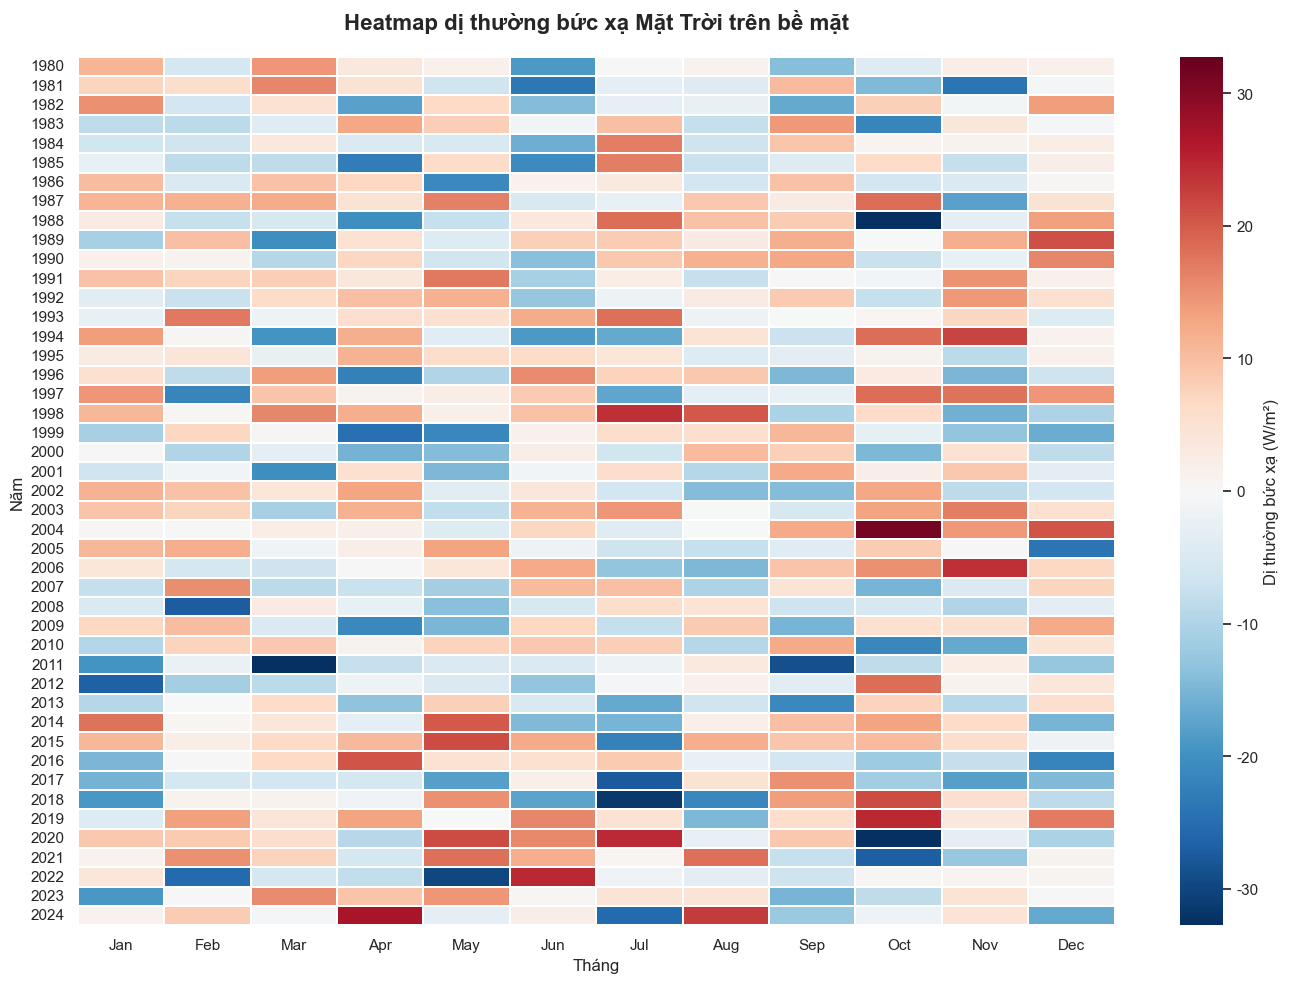

In [11]:
# Prepare the data: Pivot into Year x Month format
# Ensure time is datetime and extract year
df_anom['time'] = pd.to_datetime(df_anom['time'])
df_anom['year'] = df_anom['time'].dt.year

# Calculate monthly mean of daily anomalies to get a clean grid
monthly_anom = df_anom.groupby(['year', 'month'])['avg_snswrf'].mean().reset_index()

# Pivot the table: Rows = Year, Columns = Month
heatmap_data = monthly_anom.pivot(index='year', columns='month', values='avg_snswrf')

# Create a custom Brown-White-Yellow colormap
# Brown for negative anomalies (dimming), White for zero, Yellow/Gold for positive (brightening)
colors = ["#543005", "#bf812d", "#f5f5f5", "#f9d71c", "#d9a406"]
n_bins = 100
cmap_name = "solar_anomaly"
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

fig, ax = plt.subplots(figsize=(14, 10))

# We use a robust range (vmin/vmax) to prevent outliers from washing out the color
# Centering at 0 is critical for anomaly plots
vmax = np.abs(heatmap_data.values).max() * 0.8 # Slightly compressed for better contrast
sns.heatmap(heatmap_data, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-vmax, vmax=vmax,
            cbar_kws={'label': 'Dị thường bức xạ (W/m²)'},
            linewidths=0.05,
            ax=ax)

# Refine labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_labels)
ax.set_title("Heatmap dị thường bức xạ Mặt Trời trên bề mặt", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Năm", fontsize=12)
ax.set_xlabel("Tháng", fontsize=12)

plt.tight_layout()
plt.show()